In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
data = pd.read_csv("Clustering_Data.csv")
data

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,3
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,3
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,3
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,3


In [3]:
data = data.astype(float)

In [4]:
data = ((data - data.min())/(data.max()- data.min()))
data

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,0.842105,0.191700,0.572193,0.257732,0.619565,0.627586,0.573840,0.283019,0.593060,0.372014,0.455285,0.970696,0.561341,0.0
1,0.571053,0.205534,0.417112,0.030928,0.326087,0.575862,0.510549,0.245283,0.274448,0.264505,0.463415,0.780220,0.550642,0.0
2,0.560526,0.320158,0.700535,0.412371,0.336957,0.627586,0.611814,0.320755,0.757098,0.375427,0.447154,0.695971,0.646933,0.0
3,0.878947,0.239130,0.609626,0.319588,0.467391,0.989655,0.664557,0.207547,0.558360,0.556314,0.308943,0.798535,0.857347,0.0
4,0.581579,0.365613,0.807487,0.536082,0.521739,0.627586,0.495781,0.490566,0.444795,0.259386,0.455285,0.608059,0.325963,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.705263,0.970356,0.582888,0.510309,0.271739,0.241379,0.056962,0.735849,0.205047,0.547782,0.130081,0.172161,0.329529,1.0
174,0.623684,0.626482,0.598930,0.639175,0.347826,0.282759,0.086498,0.566038,0.315457,0.513652,0.178862,0.106227,0.336662,1.0
175,0.589474,0.699605,0.481283,0.484536,0.543478,0.210345,0.073840,0.566038,0.296530,0.761092,0.089431,0.106227,0.397290,1.0
176,0.563158,0.365613,0.540107,0.484536,0.543478,0.231034,0.071730,0.754717,0.331230,0.684300,0.097561,0.128205,0.400856,1.0


In [5]:
k = 3
def initialize_centroids(data, k):
    """
    Randomly selects k data points as initial centroids.

    Parameters:
    - data: A NumPy array of shape (178, 14), the dataset.
    - k: Number of clusters.

    Returns:
    - centroids: A NumPy array of shape (k, 14), initial centroids.
    """
    np.random.seed(99)  # For reproducibility
    centroids = data[np.random.choice(data.shape[0], k, replace=False)]
    return centroids

data = np.array(data)
initial_centroid=initialize_centroids(data,k)

def distance(data,new):
    return np.sqrt(np.sum((data - new)**2))
    


initial_centroid
    
    

array([[0.88157895, 0.22332016, 0.54545455, 0.07216495, 0.34782609,
        0.8       , 0.69620253, 0.30188679, 0.8044164 , 0.53071672,
        0.58536585, 0.63369963, 0.90513552, 0.        ],
       [0.66578947, 0.1916996 , 0.50802139, 0.28865979, 0.51086957,
        0.74827586, 0.62236287, 0.39622642, 0.60883281, 0.41382253,
        0.38211382, 0.77289377, 0.36875892, 0.        ],
       [0.73947368, 0.66798419, 0.54545455, 0.45876289, 0.20652174,
        0.28275862, 0.10337553, 0.66037736, 0.36277603, 0.65955631,
        0.07317073, 0.13553114, 0.14407989, 1.        ]])

In [6]:


F_D = []
L = []

def distances(k,F_D,data,initial_centroid):
    L = []
    for rows in data:
        L.append(rows)
    for i in L:
        for j in range(k):
            gg = float(distance(i,initial_centroid[j]))
            F_D.append(gg)

distances(k,F_D,data,initial_centroid)

In [7]:
def cluster_sort(k,F_D):
    div = []
    index = []
    for i in range(0,int(len(F_D)),k):
        L = []
        for j in range(k):
            L.append(F_D[i+j])
        div.append(min(L))
        index.append(L.index(min(L)))
    return div,index
        
        
min_value,cluster_number = cluster_sort(k,F_D)

cluster_number = pd.DataFrame(cluster_number)
F_D = pd.DataFrame(F_D)
cluster_number

,0
0,1
1,1
2,1
3,0
4,1
...,...
173,2
174,2
175,2
176,2


In [8]:
def sort_cluster_members(k,cluster_number):
    cluster_number = pd.DataFrame(cluster_number)
    sorted_members=[]
    for i in range(k):
        sorted_members.append(cluster_number[cluster_number[0] == i].index.tolist())
    return sorted_members    

members = sort_cluster_members(k,cluster_number)
members

[[3, 5, 10, 12, 13, 14, 18, 31, 50, 51],
 [0,
  1,
  2,
  4,
  6,
  7,
  8,
  9,
  11,
  15,
  16,
  17,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  71,
  72,
  73,
  74,
  76,
  78,
  79,
  80,
  81,
  82,
  84,
  85,
  86,
  87,
  88,
  89,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  106,
  108,
  109,
  110,
  111,
  113,
  114,
  115,
  116,
  117,
  119,
  120,
  121,
  124,
  125,
  126,
  128],
 [59,
  60,
  61,
  70,
  75,
  77,
  83,
  90,
  91,
  92,
  105,
  107,
  112,
  118,
  122,
  123,
  127,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,
  153,
  154,
  155,
  156,
  157,
  158,
  159,
  160,

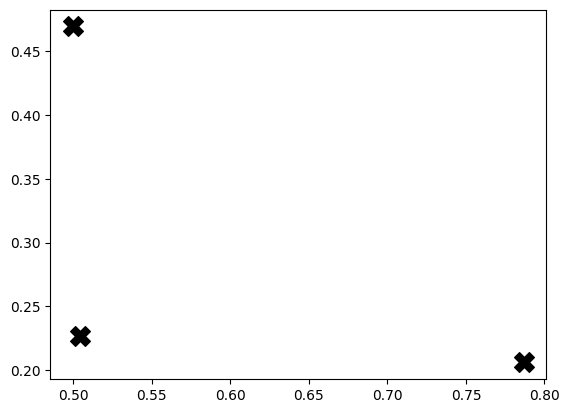

In [9]:
data = np.array(data)

def new_centroids(data_points, clusters):
    """
    Calculate new centroids based on indices of cluster members.
    
    Parameters:
    - data_points: np.array of shape (n_samples, n_features)
    - clusters: List of lists, where each sublist contains indices of members in a cluster
    
    Returns:
    - centroids: np.array of shape (k, n_features)
    """
    centroids = []
    for cluster_indices in clusters:
        cluster_points = data_points[cluster_indices]
        new_centroid = np.mean(cluster_points, axis=0)
        centroids.append(new_centroid)
    return np.array(centroids)

new_F_D=[]

centroid = new_centroids(data,members)

distances(k,new_F_D,data,centroid)

min_value,cluster_number = cluster_sort(k,new_F_D)
new_F_D = pd.DataFrame(new_F_D)

cluster_number = pd.DataFrame(cluster_number)

members = sort_cluster_members(k,cluster_number)
centroid
plt.scatter(centroid[:, 0], centroid[:, 1], label="Centroids", s=200, c="black", marker="X")

def K_MEANS(k,data,iteration = 100):
    data = np.array(data)
    F_D = []
    centroid = []
    initial_centroid = initialize_centroids(data, k)
    distances(k,F_D,data,initial_centroid)
    min_value,cluster_number = cluster_sort(k,F_D)
    cluster_number = pd.DataFrame(cluster_number)
    F_D = pd.DataFrame(F_D)
    cluster_number["Cluster_number"] = cluster_number[0]
    cluster_number = cluster_number.drop(0 , axis =1)
    members = sort_cluster_members(k,cluster_number)
    data = pd.DataFrame(data)    
    centroid = new_centroid(data,k)
    record_centroid = []
    for i in range(iteration):
        NEW_LIST = []
        data = np.array(data)
        distances(k,NEW_LIST,data,centroid)
        min_,cluster_num = cluster_sort(k,NEW_LIST)
        cluster_num = pd.DataFrame(cluster_num)
        cluster_num["Cluster_number"] = cluster_num[0]
        cluster_num = cluster_num.drop(0 , axis =1)
        NEW_LIST = pd.DataFrame(NEW_LIST)
        mem = sort_cluster_members(k,cluster_num)
        data = pd.DataFrame(data)
        centroid = new_centroid(data,k)
        if i % 30 ==0:
            print(centroid)



In [10]:
import time
from IPython.display import clear_output
def plot_clusters(data, number, centroids, i):
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(data)
    centroids_2d = pca.transform(centroids)
    plt.title(f"Iteration: {i}")
    clear_output(wait=True)
    plt.scatter(x=data_2d[:, 0], y=data_2d[:, 1], c=number)
    plt.scatter(x=centroids_2d[:, 0], y=centroids_2d[:, 1], marker='x', color='red')
    plt.show()
 
    time.sleep(2)




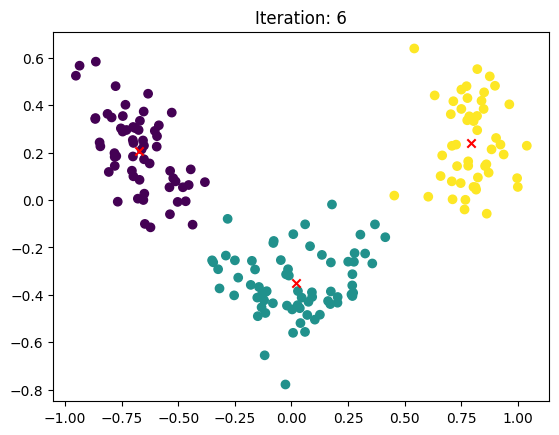

array([[0.71109649, 0.25      , 0.58716578, 0.34295533, 0.4009058 ,
        0.64408046, 0.55713783, 0.29937107, 0.4701367 , 0.35938567,
        0.47655827, 0.69358974, 0.59595816, 0.00833333],
       [0.32295957, 0.23093888, 0.46981322, 0.4878231 , 0.26134216,
        0.43883058, 0.36629365, 0.43833744, 0.38348649, 0.15170401,
        0.46808059, 0.55539629, 0.16749364, 0.5       ],
       [0.55832438, 0.5147213 , 0.57470261, 0.55869977, 0.31543922,
        0.24074595, 0.09661586, 0.60531382, 0.23755875, 0.51734345,
        0.16741331, 0.15392091, 0.24932312, 0.98979592]])

In [11]:
def K_MEANS(centroid,k,data,iteration = 100):
    centroid_a = centroid.copy()
    
    for i in range(iteration):
        new_F_D = []
        old_cen = centroid_a.copy()
        distances(k,new_F_D,data,centroid_a)
        min_value,cluster_number = cluster_sort(k,new_F_D)
        new_F_D = pd.DataFrame(new_F_D)
        cluster_number = pd.DataFrame(cluster_number)
        members = sort_cluster_members(k,cluster_number)
        centroid_a = new_centroids(data,members)
        plot_clusters(data,cluster_number,centroid_a,i+1)
        if np.array_equal(old_cen,centroid_a):
            break
    return centroid_a
    
    
    
K_MEANS(centroid,k,data,100)


### DONE___________SUCCESSFUL_____________________